# BurstCube Data Types: CBD and TTE

BurstCube produces two primary time-series science data products for each of
its four detectors (`CS0`-`CS3`):

* **CBD** (continuous binned data): a pre-binned 16-channel time history of
  counts, nominally at 0.256 s resolution. Each observation day has an
  unfiltered (`_uf`) and a cleaned (`_cl`) version.
* **TTE** (time-tagged event data): an unbinned, 1024-channel photon list.
  Unlike GBM, BurstCube never had an onboard astrophysical trigger fire, so
  TTE exists only for 7 short commissioning/validation windows across the
  whole mission.

This notebook uses **2024-05-30** (`240530`) as the worked example, since it
is one of the 7 days with both CBD and TTE data, for detector `CS0`. It walks
through finding and downloading the data, `_uf` vs `_cl`, time selection,
rebinning, light curves, count spectra, and several of the caveats that
actually bite in practice.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gdt.core import data_path
from gdt.core.binning.binned import combine_by_factor
from gdt.core.binning.unbinned import bin_by_time
from gdt.core.plot.lightcurve import Lightcurve
from gdt.core.plot.spectrum import Spectrum

from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.missions.burstcube.tte import BurstCubeTTE
from gdt.missions.burstcube.hk import BurstCubeHK
from gdt.missions.burstcube.finders import BurstCubeObsFinder
from gdt.missions.burstcube import caldb

OBS_ID = '240530'
DETECTOR = 'CS0'
%matplotlib inline

## Finding and downloading a day

Every BurstCube archive filename is fully determined by the observation day,
detector, and product type, so `BurstCubeObsFinder` does not need to list a
remote directory to know what to download -- it just downloads the exact
files. Not every day has data: day directories are **not contiguous**, and
only 7 days out of the whole mission have TTE.

In [2]:
download_dir = Path(data_path) / 'burstcube' / OBS_ID
download_dir.mkdir(parents=True, exist_ok=True)

finder = BurstCubeObsFinder()
finder.cd(OBS_ID)
print('Contents of the day directory:', finder.files)

cbd_cl_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='cl', verbose=False)
cbd_uf_path, = finder.get_cbd(download_dir, detectors=DETECTOR, variant='uf', verbose=False)
tte_path, = finder.get_tte(download_dir, detectors=DETECTOR, verbose=False)
hk_path = finder.get_hk(download_dir, verbose=False)

print('CBD (cl):', cbd_cl_path)
print('CBD (uf):', cbd_uf_path)
print('TTE:', tte_path)
print('Detector HK:', hk_path)

Contents of the day directory: ['auxil', 'events', 'monitor']


CBD (cl): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_cl.fits.gz
CBD (uf): /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_3cbd_uf.fits.gz
TTE: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530cs0_tte_uf.evt.gz
Detector HK: /root/.gammaray_data_tools/2.2.3/test_data/burstcube/240530/bc240530csa.hk.gz


## Opening CBD: `_uf` vs `_cl`

`_uf` is the unfiltered data as telemetered; `_cl` has bad/unphysical
intervals (captured in the GTIs) removed. Both are read the same way, with
`BurstCubeCBD.open()`.

In [3]:
cbd_uf = BurstCubeCBD.open(cbd_uf_path)
cbd_cl = BurstCubeCBD.open(cbd_cl_path)

print(cbd_uf)
print()
print(cbd_cl)

<BurstCubeCBD: bc240530cs0_3cbd_uf.fits.gz;
 time range (np.float64(107629262.94600001), np.float64(107654399.922));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>

<BurstCubeCBD: bc240530cs0_3cbd_cl.fits.gz;
 time range (np.float64(107629263.202), np.float64(107634882.57));
 energy range (np.float64(0.0), np.float64(1648.510009765625))>


In [4]:
print(f'_uf: {cbd_uf.data.size[0]} bins, {cbd_uf.gti.num_intervals} GTI segment(s)')
print(f'_cl: {cbd_cl.data.size[0]} bins, {cbd_cl.gti.num_intervals} GTI segment(s)')

_uf: 98188 bins, 4 GTI segment(s)
_cl: 12576 bins, 5 GTI segment(s)


## Caveat: `TIME_SYST_ERROR`

Every CBD (and TTE) row carries a per-row systematic timing uncertainty, a
consequence of BurstCube's GPS-based clock reconstruction (archive caveat
#11 has the full story: average drift per reboot 24 +/- 4.4 s, ground time
jams 38.4 +/- 2.4 s, down to 1.5 +/- 1.0 s once GPS sync was enabled). For
this particular day it happens to be a flat 1 s for every row -- do not
assume it is always constant; check it rather than ignore it.

In [5]:
print('TIME_SYST_ERROR (s): min={:.4f}  max={:.4f}  mean={:.4f}'.format(
    cbd_cl.time_syst_error.min(), cbd_cl.time_syst_error.max(),
    cbd_cl.time_syst_error.mean()))

TIME_SYST_ERROR (s): min=1.0000  max=1.0000  mean=1.0000


## Light curves

Integrating CBD over its full energy range with `to_lightcurve()` gives a
`TimeBins` object, which the `Lightcurve` plot class can render directly.

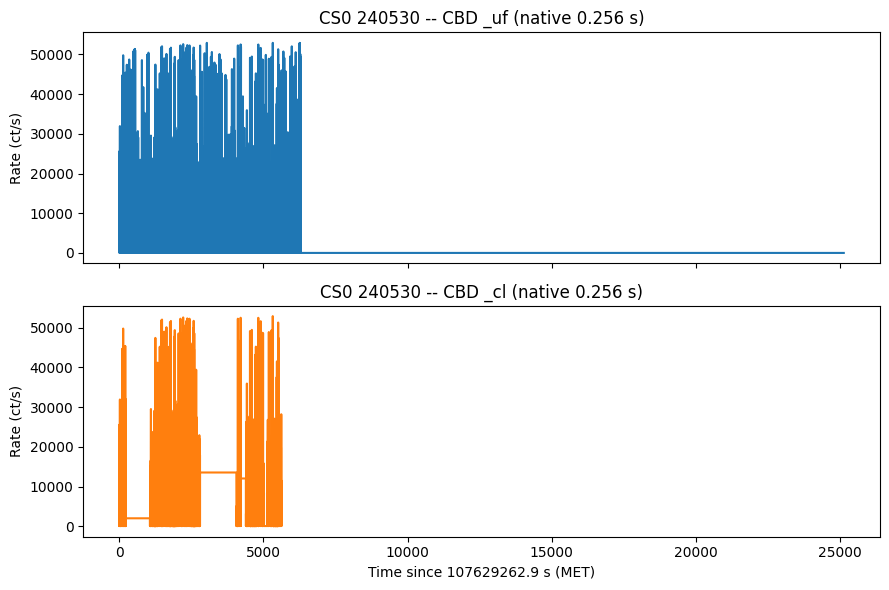

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

lc_uf = cbd_uf.to_lightcurve()
lc_cl = cbd_cl.to_lightcurve()

axes[0].step(lc_uf.lo_edges - cbd_uf.time_range[0], lc_uf.rates, where='post')
axes[0].set_title(f'{DETECTOR} {OBS_ID} -- CBD _uf (native 0.256 s)')
axes[0].set_ylabel('Rate (ct/s)')

axes[1].step(lc_cl.lo_edges - cbd_cl.time_range[0], lc_cl.rates, where='post', color='C1')
axes[1].set_title(f'{DETECTOR} {OBS_ID} -- CBD _cl (native 0.256 s)')
axes[1].set_xlabel(f'Time since {cbd_uf.time_range[0]:.1f} s (MET)')
axes[1].set_ylabel('Rate (ct/s)')

fig.tight_layout()
plt.show()

Even at native resolution, the `_cl` gaps are visible as blank stretches; the
`_uf` panel is denser but noisier and includes the intervals `_cl` removes.

## Rebinning

`Phaii.rebin_time` accepts any gdt-core binned-data rebinning function.
`combine_by_factor` merges a fixed number of consecutive bins and conserves
the total counts -- and, because gdt-core only rebins within a contiguous
run of bins, it never bridges a real gap.

**A caveat this surfaces in practice**: a handful of real bins arrive only
0.255 s after the previous one -- 1 ms short of the nominal 0.256 s
`TIMEDEL` (this is exactly what `BurstCubeCBD.blended` flags, per archive
caveat #9). The official caveat also states that CBD data blending is
*"filtered out in the archive clean files"*. What we measure here is
narrower than that: the `dt < TIMEDEL` test below flags 53 of this `_cl`
file's 12576 rows as arriving 1 ms short of the nominal cadence. Whether
that 1 ms shortfall is the same packet-cadence blending the caveat
describes, or something else `_cl` was never meant to remove, is not
something we can determine from this file alone -- we report the
measurement, not a verdict on the archive's filtering.
Under the `TIMEPIXR=1` bin-end convention, that makes the
*derived* start of that bin land 1 ms **before** the previous bin's end --
a real, if tiny, overlap, not a gap. gdt-core's rebinning refuses to merge
genuinely overlapping bins, so rebinning straight across one of these raises
rather than silently doing something undefined:

In [7]:
try:
    cbd_cl.rebin_time(combine_by_factor, 40)
except ValueError as err:
    print(f'{cbd_cl.blended.sum()} of {cbd_cl.data.size[0]} bins in this file are flagged `blended`')
    print(f'rebin_time raised: {err}')

In practice this means: rebin (and plot) a specific time window you care
about, rather than an entire raw day at once -- which is normal usage
anyway. Here we pick a clean window between two flagged bins:

window has 92 bins, 0 flagged blended: True
92 bins -> 22 bins after rebinning by a factor of 4
total counts conserved: 27500 -> 26538


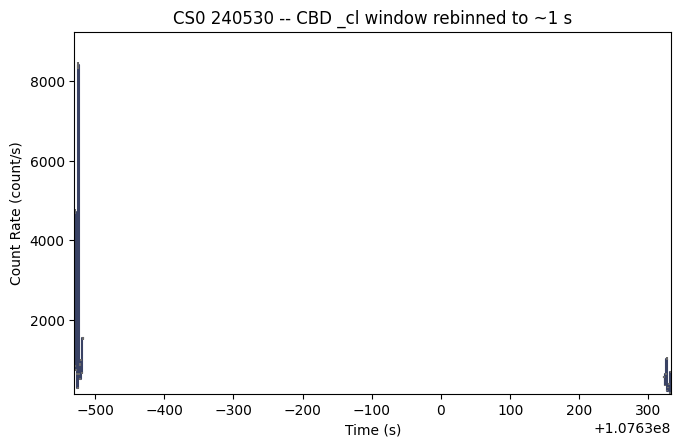

In [8]:
blended_idx = np.flatnonzero(cbd_cl.blended)
lo = cbd_cl.data.tstart[blended_idx[3] + 1]
hi = cbd_cl.data.tstart[blended_idx[4] - 1]
window = cbd_cl.slice_time([(lo, hi)])
print(f'window has {window.data.size[0]} bins, 0 flagged blended: {window.blended is None}')

rebinned = window.rebin_time(combine_by_factor, 4)  # 0.256 s -> ~1.024 s
print(f'{window.data.size[0]} bins -> {rebinned.data.size[0]} bins after rebinning by a factor of 4')
print(f'total counts conserved: {window.data.counts.sum()} -> {rebinned.data.counts.sum()}')

lcplot = Lightcurve(data=rebinned.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl window rebinned to ~1 s')
plt.show()

## Count spectra

Integrating over time instead of energy, with `to_spectrum()`, gives an
`EnergyBins` object -- the 16-channel CBD count spectrum.

/usr/local/lib/python3.11/dist-packages/gdt/core/plot/spectrum.py:154: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  self._ax.set_xlim(data.range)


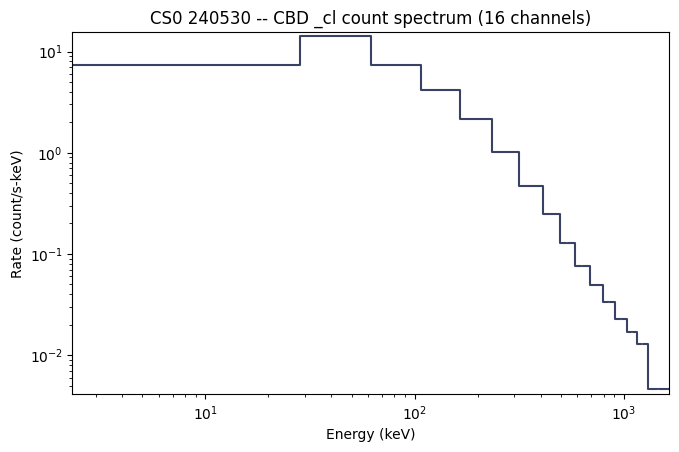

In [9]:
spectrum = cbd_cl.to_spectrum()
specplot = Spectrum(data=spectrum)
plt.title(f'{DETECTOR} {OBS_ID} -- CBD _cl count spectrum (16 channels)')
plt.show()

## TTE: unbinned events, and a header caveat that is **not** in the official document

TTE gives every photon's arrival time and 1024-channel pulse height.

Its `EVENTS` header `TSTART`/`TSTOP` cannot be trusted -- and this is **not**
a quirk of this one file, and **not** described anywhere in the official
archive caveats document. It affects **every** one of the archive's 28 TTE
files (7 days x 4 detectors), verified by reading all 28:

* all 28 store `TSTART`/`TSTOP` as FITS *strings* rather than numbers, and in
  all 28 `TSTOP - TSTART` disagrees with the file's own `ONTIME`;
* 16 of the 28 (days 240530, 240602, 240813, 240815) additionally have
  `TSTOP < TSTART`, which makes `TELAPSE`/`EXPOSURE` negative and leaves the
  primary header's `DATE-END` *earlier* than its `DATE-OBS`;
* the other 12 (days 240628, 240629, 240814) have `TSTOP > TSTART`, but the
  span still disagrees with `ONTIME`.

What *is* reliable: the `STDGTI` extension's `START`/`STOP` reproduce the
span of the actual event times **exactly** (0.000 s) in all 28 files, and
`ONTIME` agrees with that span to <= 0.7 ms. That is why `BurstCubeTTE.open()`
ignores `TSTART`/`TSTOP` entirely, derives the time range from `STDGTI` and
the events instead, and raises a `UserWarning` so the problem isn't silent.

The official caveats document's caveat #4 is about how few TTE files were
ever downlinked (34 short commissioning/validation windows, mission-wide) and
caveat #5 is about a 2024-08-15 timeline-alignment issue -- neither one
mentions these header keywords. See the README's *TTE TSTART/TSTOP are
unusable in every file* section for the full per-day table; it is not
reproduced here.

In [10]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    tte = BurstCubeTTE.open(tte_path)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')

print(tte)
print(f'{tte.data.size} events, energy range {tte.energy_range} keV')

<BurstCubeTTE: bc240530cs0_tte_uf.evt.gz;
 time range (np.float64(107629263.534), np.float64(107629558.606));
 energy range (16.219999313354492, 1429.68994140625)>
6364 events, energy range (16.219999313354492, 1429.68994140625) keV


## Binning TTE

`to_phaii()` bins the event list in time using any gdt-core unbinned-data
binning function, such as `bin_by_time` for a fixed bin width -- here, the
same 0.256 s as native CBD.

6364 events -> 6364 total binned counts (must match exactly) in 1153 bins


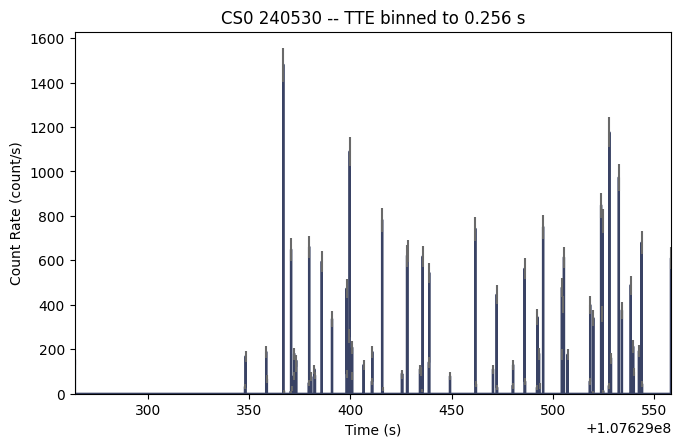

In [11]:
from gdt.core.phaii import Phaii

tte_phaii = tte.to_phaii(bin_by_time, 0.256, phaii_class=Phaii)
print(f'{tte.data.size} events -> {tte_phaii.data.counts.sum():.0f} total binned counts '
     f'(must match exactly) in {tte_phaii.data.size[0]} bins')

lcplot = Lightcurve(data=tte_phaii.to_lightcurve())
plt.title(f'{DETECTOR} {OBS_ID} -- TTE binned to 0.256 s')
plt.show()

## TTE vs CBD: day 240814, detector `CS0`

The rest of this notebook uses **2024-05-30**. This section switches to a
different one of the 7 TTE days, **2024-08-14** (`240814`), still detector
`CS0`, because that day has both a long clean stretch where CBD and TTE can
be compared directly and a striking CBD-only feature that is worth seeing on
its own. Download its CBD (`_uf`, `_cl`) and TTE products the same way as at
the top of the notebook.

In [12]:
TTE_DAY = '240814'

day_download_dir = Path(data_path) / 'burstcube' / TTE_DAY
day_download_dir.mkdir(parents=True, exist_ok=True)

day_finder = BurstCubeObsFinder()
day_finder.cd(TTE_DAY)

day_cbd_uf_path, = day_finder.get_cbd(day_download_dir, detectors=DETECTOR, variant='uf', verbose=False)
day_cbd_cl_path, = day_finder.get_cbd(day_download_dir, detectors=DETECTOR, variant='cl', verbose=False)
day_tte_path, = day_finder.get_tte(day_download_dir, detectors=DETECTOR, verbose=False)

day_cbd_uf = BurstCubeCBD.open(day_cbd_uf_path)
day_cbd_cl = BurstCubeCBD.open(day_cbd_cl_path)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    day_tte = BurstCubeTTE.open(day_tte_path)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')

day_t0, day_t1 = day_tte.time_range
print(f'{TTE_DAY} {DETECTOR} TTE: {day_tte.data.size} events, '
     f'MET {day_t0:.3f} to {day_t1:.3f} ({day_t1 - day_t0:.2f} s)')
print(f'{TTE_DAY} {DETECTOR} CBD _uf: {day_cbd_uf.data.size[0]} bins; '
     f'_cl: {day_cbd_cl.data.size[0]} bins')

240814 CS0 TTE: 11945 events, MET 114214208.408 to 114214432.668 (224.26 s)
240814 CS0 CBD _uf: 86322 bins; _cl: 44383 bins


### Step 1: TTE binned in time, against CBD

Bin TTE at CBD's native 0.256 s with `to_phaii` and plot both light curves
over the full TTE span.

TTE arrives in short blocks separated by longer gaps, so its light curve
reads exactly zero over much of the span. Before reading anything into a
comparison, it is worth establishing *why* those gaps are empty: "the sky
was quiet" and "TTE wrote no events" look identical in a TTE-only plot. CBD
watches the same detector continuously, so it can tell them apart.


94 TTE recording blocks at a 0.5 s gap threshold, 97.1 s of live time in a 224.3 s nominal span
CBD _uf: 885 bins inside the TTE span


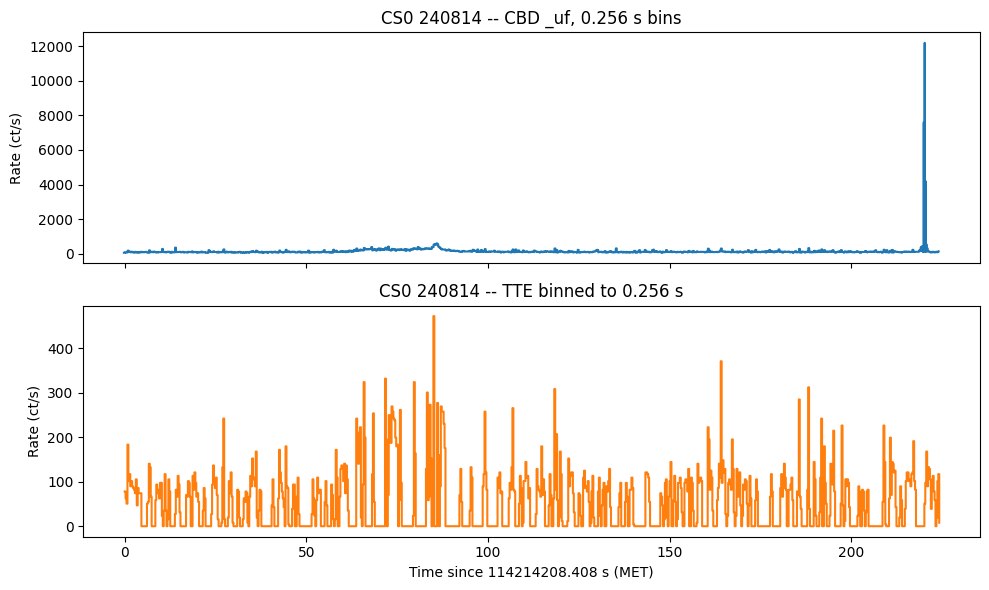

In [13]:
def active_blocks(times, gap_threshold):
    """Split sorted event times into contiguous recording blocks, wherever
    the gap to the next event exceeds `gap_threshold`."""
    dt = np.diff(times)
    gap_idx = np.flatnonzero(dt > gap_threshold)
    starts = np.concatenate(([0], gap_idx + 1))
    stops = np.concatenate((gap_idx, [times.size - 1]))
    return list(zip(times[starts], times[stops]))


GAP_THRESHOLD = 0.5  # s

day_event_times = np.sort(day_tte.data.times)
day_blocks = active_blocks(day_event_times, GAP_THRESHOLD)
day_active_s = sum(stop - start for start, stop in day_blocks)
day_nominal_span = day_t1 - day_t0

print(f'{len(day_blocks)} TTE recording blocks at a {GAP_THRESHOLD} s gap '
     f'threshold, {day_active_s:.1f} s of live time in a '
     f'{day_nominal_span:.1f} s nominal span')

day_tte_phaii = day_tte.to_phaii(bin_by_time, 0.256, phaii_class=Phaii)
day_cbd_uf_span = day_cbd_uf.slice_time([(day_t0, day_t1)])
print(f'CBD _uf: {day_cbd_uf_span.data.size[0]} bins inside the TTE span')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

lc_cbd = day_cbd_uf_span.to_lightcurve()
lc_tte = day_tte_phaii.to_lightcurve()

axes[0].step(lc_cbd.lo_edges - day_t0, lc_cbd.rates, where='post', color='C0')
axes[0].set_title(f'{DETECTOR} {TTE_DAY} -- CBD _uf, 0.256 s bins')
axes[0].set_ylabel('Rate (ct/s)')

axes[1].step(lc_tte.lo_edges - day_t0, lc_tte.rates, where='post', color='C1')
axes[1].set_title(f'{DETECTOR} {TTE_DAY} -- TTE binned to 0.256 s')
axes[1].set_xlabel(f'Time since {day_t0:.3f} s (MET)')
axes[1].set_ylabel('Rate (ct/s)')

fig.tight_layout()
plt.show()

In [14]:
# Are the TTE gaps quiet sky, or intervals where TTE wrote nothing?
# CBD observes the same detector continuously, so compare its rate inside
# the TTE blocks against its rate inside the TTE gaps.
uf = day_cbd_uf.data
in_span = (uf.tstart >= day_t0) & (uf.tstop <= day_t1)

in_block = np.zeros(uf.num_times, bool)
touches_block = np.zeros(uf.num_times, bool)
for start, stop in day_blocks:
    in_block |= (uf.tstart >= start) & (uf.tstop <= stop)
    touches_block |= (uf.tstop > start) & (uf.tstart < stop)
in_gap = in_span & ~touches_block

edges = np.sort(day_event_times)
for label, mask in (('inside a TTE block', in_block & in_span),
                    ('inside a TTE gap', in_gap)):
    counts = uf.counts[mask].sum()
    exposure = uf.exposure[mask].sum()
    n_tte = int((np.searchsorted(edges, uf.tstop[mask]) -
                 np.searchsorted(edges, uf.tstart[mask])).sum())
    print(f'{label:20s} {mask.sum():4d} bins  {exposure:7.2f} s   '
          f'CBD {counts:6d} cts = {counts / exposure:6.1f} ct/s   '
          f'TTE {n_tte:5d} events = {n_tte / exposure:6.1f} ct/s')

# what the instrument housekeeping reports about TTE capture over the span
day_hk = BurstCubeHK.open(day_finder.get_hk(day_download_dir, verbose=False))
hk_time = np.asarray(day_hk.hk1['time'].value, dtype=float)  # Time column -> MET
near = (hk_time >= day_t0 - 30) & (hk_time <= day_t1 + 30)
print(f"\nDETECTOR_HK1 TTE_ENABLED across the span: "
      f"{np.unique(day_hk.tte_enabled()[near])} from {near.sum()} samples "
      f"at {np.median(np.diff(hk_time[near])):.0f} s cadence")


inside a TTE block    292 bins    73.48 s   CBD   9108 cts =  124.0 ct/s   TTE  8683 events =  118.2 ct/s
inside a TTE gap      406 bins   102.59 s   CBD  13611 cts =  132.7 ct/s   TTE     0 events =    0.0 ct/s



DETECTOR_HK1 TTE_ENABLED across the span: [1] from 9 samples at 30 s cadence


CBD counts at essentially the same rate inside the TTE gaps as inside the
TTE blocks, while TTE records **exactly zero** events across roughly 103 s
of those gaps. At TTE's own in-block rate that stretch should have held
something like twelve thousand events. The gaps are therefore not quiet
sky: the detector was still seeing photons at its normal rate while TTE
wrote nothing.

Why it wrote nothing is not something this data answers. The instrument
housekeeping reports `TTE_ENABLED = 1` at every sample spanning the window,
so it is not a simple capture on/off -- though at 30 s cadence that flag
cannot resolve blocks lasting a fraction of a second either way. We report
the measurement and leave the mechanism alone.

The practical consequence matters more than the cause: **a TTE count rate
has to be computed over the time TTE actually recorded, not over its
nominal span.** Dividing the event count by the full span measures the duty
cycle, not a rate -- which is why Step 3 compares the two instruments only
over CBD bins that lie entirely inside a TTE recording block.


### Step 2: a CBD spike with no TTE counterpart

There is a sharp, narrow feature in the CBD light curve just above, at MET
114214428.0-114214429.2 (t-t0 = 219.6-220.8 s). Zoom in on it and look at
what CBD's own per-bin diagnostics say about it.

In [15]:
spike_lo, spike_hi = 114214428.0, 114214429.2

uf_tstart = day_cbd_uf.data.tstart
uf_tstop = day_cbd_uf.data.tstop
uf_counts = day_cbd_uf.data.counts.sum(axis=1)
uf_exposure = day_cbd_uf.data.exposure

spike_mask = (uf_tstart >= spike_lo) & (uf_tstop <= spike_hi)
spike_idx = np.flatnonzero(spike_mask)

spike_counts = uf_counts[spike_idx].sum()
spike_exposure = uf_exposure[spike_idx].sum()

print(f'{spike_idx.size} consecutive CBD bins in the window, '
     f'all flagged blended: {day_cbd_uf.blended[spike_idx].all()}')
print(f'exposure per bin (s): min={uf_exposure[spike_idx].min():.3f} '
     f'max={uf_exposure[spike_idx].max():.3f} (nominal is 0.256 s)')
print(f'{spike_counts:.0f} counts over {spike_exposure:.3f} s summed exposure '
     f'= {spike_counts / spike_exposure:.0f} ct/s')

per_bin_rate = uf_counts[spike_idx] / uf_exposure[spike_idx]
print(f'plotted per-bin (counts/exposure), the individual bins reach up to '
     f'{per_bin_rate.max():.0f} ct/s -- an artifact of one bin having only '
     f'{uf_exposure[spike_idx][np.argmax(per_bin_rate)] * 1000:.0f} ms of '
     'exposure, not a real count rate')

baseline_mask = (((uf_tstart >= spike_lo - 5) & (uf_tstop <= spike_lo)) |
                 ((uf_tstart >= spike_hi) & (uf_tstop <= spike_hi + 5)))
baseline_mask &= ~day_cbd_uf.blended
baseline_rate = uf_counts[baseline_mask].sum() / uf_exposure[baseline_mask].sum()
print(f'baseline rate in the 5 s immediately either side (non-blended bins): '
     f'{baseline_rate:.0f} ct/s')

tte_in_window = ((day_tte.data.times >= spike_lo) &
                 (day_tte.data.times <= spike_hi)).sum()
print(f'TTE events in the same wall-clock window: {tte_in_window}')

12 consecutive CBD bins in the window, all flagged blended: True
exposure per bin (s): min=0.005 max=0.189 (nominal is 0.256 s)
376 counts over 1.096 s summed exposure = 343 ct/s
plotted per-bin (counts/exposure), the individual bins reach up to 12200 ct/s -- an artifact of one bin having only 5 ms of exposure, not a real count rate
baseline rate in the 5 s immediately either side (non-blended bins): 112 ct/s
TTE events in the same wall-clock window: 65


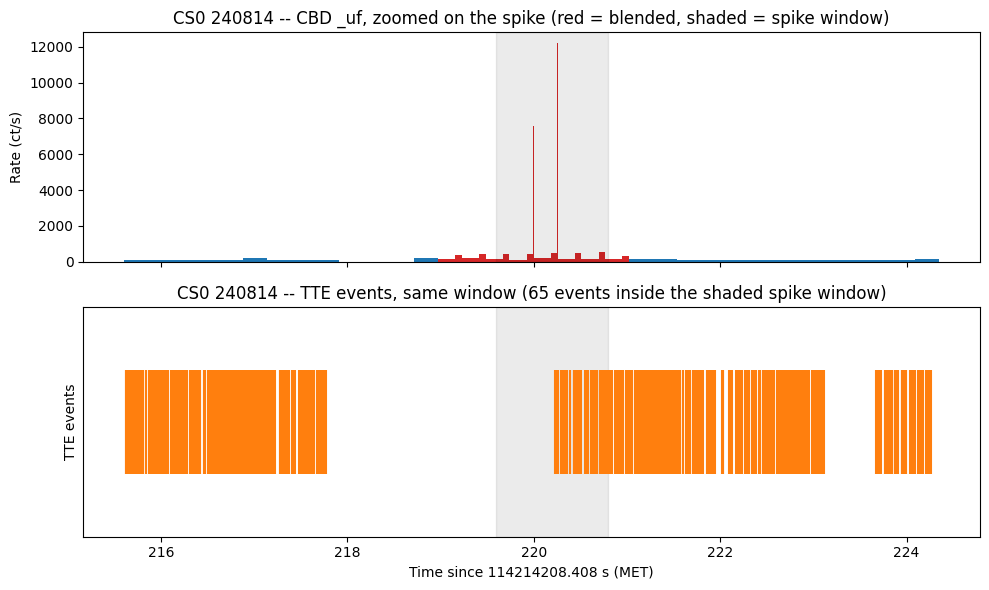

In [16]:
zoom_lo, zoom_hi = spike_lo - 4, spike_hi + 4
zoom_mask = (uf_tstart >= zoom_lo) & (uf_tstop <= zoom_hi)
zoom_idx = np.flatnonzero(zoom_mask)
zoom_rate = uf_counts[zoom_idx] / uf_exposure[zoom_idx]

tte_zoom_mask = (day_tte.data.times >= zoom_lo) & (day_tte.data.times <= zoom_hi)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

colors = np.where(day_cbd_uf.blended[zoom_idx], 'C3', 'C0')
axes[0].bar(uf_tstart[zoom_idx] - day_t0, zoom_rate,
           width=uf_exposure[zoom_idx], align='edge', color=colors)
axes[0].axvspan(spike_lo - day_t0, spike_hi - day_t0, color='k', alpha=0.08)
axes[0].set_title(f'{DETECTOR} {TTE_DAY} -- CBD _uf, zoomed on the spike '
                  '(red = blended, shaded = spike window)')
axes[0].set_ylabel('Rate (ct/s)')

axes[1].eventplot(day_tte.data.times[tte_zoom_mask] - day_t0, color='C1',
                  lineoffsets=0, linelengths=0.8)
axes[1].axvspan(spike_lo - day_t0, spike_hi - day_t0, color='k', alpha=0.08)
axes[1].set_title(f'{DETECTOR} {TTE_DAY} -- TTE events, same window '
                  f'({tte_in_window} events inside the shaded spike window)')
axes[1].set_xlabel(f'Time since {day_t0:.3f} s (MET)')
axes[1].set_ylabel('TTE events')
axes[1].set_yticks([])

fig.tight_layout()
plt.show()

This is archive **caveat #9**, not caveat #10. Caveat #9 is CBD data
blending: a packet cadence below the nominal 0.256 s `TIMEDEL` mixes
telemetry from different periods, which is exactly what all 12 bins being
flagged `blended` (`BurstCubeCBD.blended`) with exposures as short as
5 ms means. Caveat #10 is a different thing -- genuine, physically
impossible *high counts at full 0.256 s exposure* -- and it does occur
elsewhere in the archive (day 240530, detector `CS0`, has 366 such bins
inside its TTE span, up to 12745 counts in a single 0.256 s bin), but not in
this window: every one of these 12 bins has short, not nominal, exposure. Do
not mistake this spike for caveat #10.

Caveat #9 also states that blended data "are filtered out in the archive
clean files". Check that directly against `_cl`:

In [17]:
cl_tstart = day_cbd_cl.data.tstart
cl_tstop = day_cbd_cl.data.tstop
cl_in_spike = ((cl_tstop > spike_lo) & (cl_tstart < spike_hi)).sum()

print(f'{TTE_DAY} {DETECTOR} CBD: _uf has {day_cbd_uf.data.size[0]} bins, '
     f'_cl has {day_cbd_cl.data.size[0]} bins -- filtering clearly happened')
print(f'_cl bins overlapping the spike window: {cl_in_spike}')

order = np.argsort(uf_exposure[spike_idx])
print('\nthe 3 shortest-exposure (most extreme) bins in the spike, and '
     'whether a bin with the same TIME is present in _cl:')
for k in order[:3]:
    i = spike_idx[k]
    close = np.isclose(cl_tstop, uf_tstop[i], atol=1e-3, rtol=0.0)
    print(f'  tstop={uf_tstop[i]:.4f}  exposure={uf_exposure[i] * 1000:.1f} ms '
         f'  counts={uf_counts[i]:.0f}  present in _cl: {close.any()}')

240814 CS0 CBD: _uf has 86322 bins, _cl has 44383 bins -- filtering clearly happened
_cl bins overlapping the spike window: 0

the 3 shortest-exposure (most extreme) bins in the spike, and whether a bin with the same TIME is present in _cl:
  tstop=114214428.6630  exposure=5.0 ms   counts=61  present in _cl: False
  tstop=114214428.9190  exposure=5.0 ms   counts=21  present in _cl: False
  tstop=114214428.4070  exposure=5.0 ms   counts=38  present in _cl: False


Executed against the real files, none of the 12 flagged bins -- including
the 3 shortest-exposure ones -- survive into `_cl`: `_cl` has zero bins
anywhere in the spike window. Whatever holds for blended bins elsewhere in
the archive, in this particular window caveat #9's filtering removed all of
them, not just most; we report that as what this file actually shows rather
than assume a partial survival we have not seen.

### Step 3: a clean range, compared in energy

Restrict to MET 114214208.408-114214420.0, the 211.6 s before the anomaly.
Within that range, use only the CBD bins that lie *entirely inside* a TTE
recording block (the same block-finding as Step 1, 0.5 s gap threshold), so
both instruments see identical intervals and no rate scaling is needed.

In [18]:
clean_lo, clean_hi = 114214208.408, 114214420.0

clean_blocks = []
for block_start, block_stop in day_blocks:
    clipped_start, clipped_stop = max(block_start, clean_lo), min(block_stop, clean_hi)
    if clipped_stop > clipped_start:
        clean_blocks.append((clipped_start, clipped_stop))

matched_mask = np.zeros(uf_tstart.size, dtype=bool)
for block_start, block_stop in clean_blocks:
    matched_mask |= (uf_tstart >= block_start) & (uf_tstop <= block_stop)
matched_idx = np.flatnonzero(matched_mask)
matched_exposure = uf_exposure[matched_idx].sum()

print(f'{len(clean_blocks)} TTE blocks inside the clean range -> '
     f'{matched_idx.size} matched CBD bins, {matched_exposure:.2f} s')

90 TTE blocks inside the clean range -> 261 matched CBD bins, 66.82 s


Regroup TTE's 1024 native channels to CBD's 16 using the CALDB `reb16`
scheme directly (`gdt.missions.burstcube.caldb.rebin('CS0', 16)`), counting
each event into the channel whose `[chan_min, chan_max]` contains its `PHA`.
This mapping is exact: the CALDB `reb16` group boundaries reproduce the
`eb16` energy edges for this detector, so TTE group *i* and CBD channel *i*
span identical energies -- no interpolation or approximation involved.
Restrict TTE events to the exact union of the 261 matched CBD bin windows,
so both sides cover precisely the same intervals.

In [19]:
matched_cbd_counts = day_cbd_uf.data.counts[matched_idx].sum(axis=0)

reb16 = caldb.rebin(DETECTOR, 16)
eb16 = caldb.ebounds(DETECTOR, 16)

matched_starts = uf_tstart[matched_idx]
matched_stops = uf_tstop[matched_idx]
tte_in_matched = np.zeros(day_tte.data.times.size, dtype=bool)
for bin_start, bin_stop in zip(matched_starts, matched_stops):
    tte_in_matched |= (day_tte.data.times >= bin_start) & (day_tte.data.times < bin_stop)

matched_pha = day_tte.data.channels[tte_in_matched]
matched_tte_counts = np.array([
    np.count_nonzero((matched_pha >= lo_ch) & (matched_pha <= hi_ch))
    for lo_ch, hi_ch in zip(reb16.chan_min, reb16.chan_max)
])

cbd_total, tte_total = matched_cbd_counts.sum(), matched_tte_counts.sum()
ratio_total = cbd_total / tte_total
ratio_err = ratio_total * np.sqrt(1 / cbd_total + 1 / tte_total)

print(f'total: CBD {cbd_total}   TTE {tte_total}   '
     f'ratio {ratio_total:.4f} +/- {ratio_err:.4f}\n')
print(f'{"chan":>4} {"E range (keV)":>16} {"CBD":>8} {"TTE":>8} {"ratio":>7}')
for i in range(16):
    erange = f'{eb16.low_edges()[i]:.1f}-{eb16.high_edges()[i]:.1f}'
    if matched_tte_counts[i] > 0:
        r = f'{matched_cbd_counts[i] / matched_tte_counts[i]:.2f}'
    else:
        r = 'n/a'
    print(f'{i:4d} {erange:>16} {matched_cbd_counts[i]:8d} {matched_tte_counts[i]:8d} {r:>7}')

total: CBD 8220   TTE 7959   ratio 1.0328 +/- 0.0162

chan    E range (keV)      CBD      TTE   ratio
   0         0.0-28.5        0        0     n/a
   1        28.5-62.2       13       13    1.00
   2       62.2-106.9     2861     2748    1.04
   3      106.9-165.6     2317     2241    1.03
   4      165.6-233.9     1135     1093    1.04
   5      233.9-316.5      577      564    1.02
   6      316.5-410.8      343      341    1.01
   7      410.8-494.5      300      296    1.01
   8      494.5-585.1      137      135    1.01
   9      585.1-686.0      108      106    1.02
  10      686.0-792.3       99       95    1.04
  11      792.3-907.6       73       73    1.00
  12     907.6-1030.3       60       59    1.02
  13    1030.3-1160.7       73       74    0.99
  14    1160.7-1298.8       57       55    1.04
  15    1298.8-1648.5       67       66    1.02


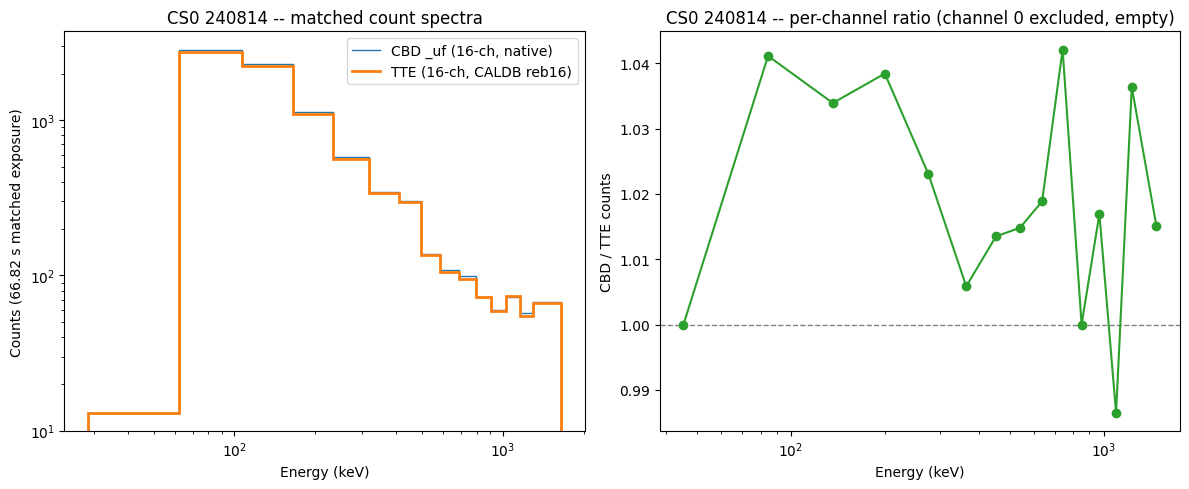

In [20]:
edges16 = np.append(eb16.low_edges(), eb16.high_edges()[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].stairs(matched_cbd_counts, edges16, label='CBD _uf (16-ch, native)', color='C0')
axes[0].stairs(matched_tte_counts, edges16, label='TTE (16-ch, CALDB reb16)',
              color='C1', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Energy (keV)')
axes[0].set_ylabel(f'Counts ({matched_exposure:.2f} s matched exposure)')
axes[0].set_title(f'{DETECTOR} {TTE_DAY} -- matched count spectra')
axes[0].legend()

chan_mid = 0.5 * (edges16[:-1] + edges16[1:])
with np.errstate(divide='ignore', invalid='ignore'):
    per_chan_ratio = matched_cbd_counts / matched_tte_counts
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].plot(chan_mid[1:], per_chan_ratio[1:], 'o-', color='C2')
axes[1].set_xscale('log')
axes[1].set_xlabel('Energy (keV)')
axes[1].set_ylabel('CBD / TTE counts')
axes[1].set_title(f'{DETECTOR} {TTE_DAY} -- per-channel ratio (channel 0 excluded, empty)')

fig.tight_layout()
plt.show()

Once the anomalous interval is excluded and the two instruments' intervals are
matched exactly, CBD and TTE agree to within a few percent across the whole
spectrum, with no systematic trend with energy. Channel 0 (below ~28.5 keV)
carries almost no counts in either instrument: by August 2024 the per-detector
low-energy trigger thresholds had already been raised to roughly 100 keV (the
mid-mission change covered in the next section), so channel 0 sits below both
instruments' thresholds.

## Caveat: the mid-mission energy threshold change

Per archive caveat #7, the per-detector low-energy trigger thresholds were
raised roughly mid-mission (from ~21-30 keV to ~100 keV) to suppress a
non-Poissonian noise component. `DETECTOR_HK2`'s `PEAK_THRES`/`BASE_THRES`
columns (60 s cadence, one value per detector) are how that shows up in the
housekeeping data; a single day's file only shows one side of that change,
so comparing an early-mission and late-mission day's HK is what actually
demonstrates it.

In [21]:
hk = BurstCubeHK.open(hk_path)
peak = hk.peak_threshold(DETECTOR)
print(f'{OBS_ID} {DETECTOR} PEAK_THRES (mV), first/last HK2 row: {peak[0]:.2f} / {peak[-1]:.2f}')
print(f'DET_ENABLED (all 4 detectors), first HK1 row: {hk.det_enabled()[0]}')

240530 CS0 PEAK_THRES (mV), first/last HK2 row: 6.00 / 6.00
DET_ENABLED (all 4 detectors), first HK1 row: [0 0 0 0]


## Summary

* CBD is pre-binned (16 channels); TTE is unbinned (1024 channels, folds to
  64 to match the full response binning).
* `_uf` keeps everything; `_cl` removes bad/unphysical intervals.
* At least one real TTE file's header timing keywords are broken; the
  reader works around it and tells you so.
* Detector thresholds changed mid-mission; `DETECTOR_HK2` is where to look.